<a id="phase3-top"></a>

# Phase 3 AI Shield: Forensic + Semantic GLM Fusion

This is the Phase 3 fusion appendix for AI Shield. Use the clickable navigation below to jump through the GLM fusion story.


<!-- AI_SHIELD_TOC -->
## Phase 3 Quick Navigation

This page is the reading map for the final fusion notebook. The links jump to the sections that explain how the forensic and semantic branches become one final probability.

| Section | Why it matters |
|---|---|
| <a href="#phase3-framing">How to read this phase</a> | Explains why Phase 3 is a meta-layer, not another image model. |
| <a href="#phase3-plan">Plan alignment</a> | How the ChatGPT fusion plan matches the real saved artifacts. |
| <a href="#phase3-glm-idea">GLM idea</a> | Why the final model is a binomial GLM instead of naive averaging. |
| <a href="#phase3-config">Config</a> | Root folders, run flags, split fractions, and model version. |
| <a href="#phase3-paths">Paths</a> | Which Phase 1, Phase 2, and Phase 3 artifacts are loaded/saved. |
| <a href="#phase3-features">Feature columns</a> | The 11 forensic and 6 semantic features used by the GLM. |
| <a href="#phase3-merge">Merge caches</a> | The 7,000-row forensic + semantic alignment check. |
| <a href="#phase3-split">Fusion split</a> | Train/validation/test split without leakage. |
| <a href="#phase3-metrics-code">Metric helpers</a> | Metrics and plotting helpers used for evaluation. |
| <a href="#phase3-glm-experiment">GLM experiment</a> | Training/loading forensic-only and full GLM models. |
| <a href="#phase3-final-eval">Final evaluation</a> | AUC, F1, Brier, reliability, ROC/PR, confusion matrix, subgroup results. |
| <a href="#phase3-coefficients">Coefficients</a> | What the standardized GLM weights mean. |
| <a href="#phase3-summary">Executive summary</a> | Final interpretation of Phase 3. |
| <a href="#phase3-references">References</a> | Sources and implementation references. |

> PDF/export note: this uses the same raw HTML anchor-link style as the Phase 1 notebook because that is the style the Telegram exporter preserved as clickable links.


## PDF Report Copy Note

This is a PDF-friendly copy of the executed Phase 3 notebook. The original Colab notebook stays executable. In this copy, I shorten setup/helper code where possible, but I keep the actual metric outputs, plots, coefficient table, and interpretation markdown.


<a id="phase3-framing"></a><a name="phase3-framing"></a>

## How to Read This Phase 3 Report

This phase does not train another image model. It turns the already-saved Phase 1 forensic outputs and Phase 2 semantic outputs into one feature table, then trains a small GLM meta-layer. The smooth reading path is: artifact alignment, feature merge, leakage-safe split, GLM training, final metrics, then coefficient interpretation.

This notebook is the fusion layer of my AI Shield pipeline.

At this point I am **not training another image model**. Phase 1 and Phase 2 already did the expensive image modeling:

- **Phase 1 forensic layer:** EfficientNet, VAE, face-gated OpenForensics.
- **Phase 2 semantic layer:** ViT patch tokens plus my custom multi-head self-attention head.

This notebook takes the saved outputs from those two phases and trains a small final model on top of them. That final model is a **late-fusion meta-layer**.

The mental picture is:

```text
Image
 ├── Phase 1 forensic branch
 │      -> low-level artifact / face / anomaly evidence
 │
 ├── Phase 2 semantic branch
 │      -> patch-relationship / scene-consistency evidence
 │
 └── Phase 3 fusion GLM
        -> final fake probability
```

The final model is a binomial GLM with a logit link, which is the same thing as logistic regression for binary classification. I am using it first because it is interpretable: every evidence feature gets a learned coefficient.


<a id="phase3-plan"></a><a name="phase3-plan"></a>

## Is the ChatGPT Fusion Plan Aligned With What I Actually Have?

Mostly yes, but I need to adapt it to the real saved artifacts.

The correct part is this:

- Fusion should be late fusion / stacking.
- I should not retrain EfficientNet, VAE, OpenForensics, or the semantic ViT model here.
- I should merge saved branch-output tables by `image_id` and `label`.
- I should train a small GLM meta-layer on the merged feature table.
- I should compare against the individual branches and not pretend that a simple average is the final method.

The adjustment is this:

Phase 1 currently has a forensic branch cache for the **7,000 original Tiny-GenImage validation images**:

```text
AI_Shield_Phase1/late_fusion_face_gated_v1/cache/branch_outputs_v1.csv
```

Phase 2 has semantic outputs for all semantic splits, **35,000 rows total**:

```text
AI_Shield_Phase2_Semantic/semantic_vit_transformer_attention_v1/cache/semantic_branch_outputs_v1.csv
```

Only the Phase 2 `semantic_test` rows correspond to the same 7,000 original validation images used by the Phase 1 forensic cache. So this notebook merges:

```text
Phase 1 forensic validation rows
+
Phase 2 semantic_test rows
=
7,000 aligned fusion rows
```

Then I split those 7,000 aligned rows into fusion train / validation / test. This avoids training the final GLM on the same rows used for final reporting.


<a id="phase3-glm-idea"></a><a name="phase3-glm-idea"></a>

## Why This Is a GLM and Not Just Averaging

A simple average would assume:

```text
forensic score and semantic score are equally reliable for every image
```

That is too naive. The VAE may be noisy. OpenForensics should only matter when a meaningful face exists. EfficientNet may be the strongest broad forensic signal. The semantic ViT branch may help when the image has clean pixels but strange object/scene relationships.

The GLM learns this from data:

$$
y_i \sim \operatorname{Bernoulli}(p_i)
$$

$$
\operatorname{logit}(p_i)
=
\beta_0
+ \beta_1 x_{i1}
+ \beta_2 x_{i2}
+ \cdots
+ \beta_k x_{ik}
$$

Then:

$$
p_i = P(\text{fake}\mid x_i)
=
\sigma(z_i)
=
\frac{1}{1+e^{-z_i}}
$$

For this project, the equation means something like:

$$
\operatorname{logit}(P(\text{fake}))
=
\beta_0
+ \beta_1 \cdot \text{EffNet score}
+ \beta_2 \cdot \text{VAE anomaly}
+ \beta_3 \cdot \text{OpenForensics fake score}
+ \beta_4 \cdot \text{semantic ViT score}
+ \beta_5 \cdot \text{attention focus}
+ \cdots
$$

A positive coefficient pushes the final decision toward fake. A negative coefficient pushes it toward real. A larger absolute coefficient means the GLM trusted that feature more after standardization.


## 1. Install Dependencies

Colab normally has these, but this keeps the notebook self-contained.

> **Report copy note:** The package install cell is omitted here so the PDF does not spend space on environment setup. The executable Colab notebook keeps it.


## 2. Imports

This notebook works with saved CSV outputs, not raw image tensors. The main libraries are Pandas for tables, scikit-learn for the GLM, and Matplotlib for the report plots.

> **Report copy note:** The import block is standard Python/sklearn setup. I omit it from the PDF copy and keep the important model/result cells visible.


<a id="phase3-config"></a><a name="phase3-config"></a>

## 3. Global Config

The important safety rule is the same as the earlier notebooks:

```text
load existing artifacts first, do not rebuild unless FORCE_REBUILD=True
```

Training the GLM is fast, but I still save it because I want the final report to be reproducible.


In [3]:
@dataclass
class Phase3FusionConfig:
    DRIVE_ROOT: str = "/content/drive/MyDrive"
    PHASE1_DIRNAME: str = "AI_Shield_Phase1"
    PHASE2_DIRNAME: str = "AI_Shield_Phase2_Semantic"
    PHASE2_VERSION: str = "semantic_vit_transformer_attention_v1"
    PHASE3_DIRNAME: str = "AI_Shield_Phase3_Fusion"
    VERSION: str = "forensic_semantic_glm_v1"

    random_seed: int = 156
    fusion_train_fraction: float = 0.60
    fusion_val_fraction: float = 0.20
    fusion_test_fraction: float = 0.20

    logistic_C: float = 1.0
    logistic_max_iter: int = 5000
    threshold_grid_size: int = 99

    FORCE_REBUILD: bool = False
    RESUME: bool = True


CONFIG = Phase3FusionConfig()

RUN_MERGE_STAGE = True
RUN_GLM_FUSION_STAGE = True
RUN_EVALUATION_STAGE = True

print(json.dumps(asdict(CONFIG), indent=2))
print({
    "RUN_MERGE_STAGE": RUN_MERGE_STAGE,
    "RUN_GLM_FUSION_STAGE": RUN_GLM_FUSION_STAGE,
    "RUN_EVALUATION_STAGE": RUN_EVALUATION_STAGE,
})

{
  "DRIVE_ROOT": "/content/drive/MyDrive",
  "PHASE1_DIRNAME": "AI_Shield_Phase1",
  "PHASE2_DIRNAME": "AI_Shield_Phase2_Semantic",
  "PHASE2_VERSION": "semantic_vit_transformer_attention_v1",
  "PHASE3_DIRNAME": "AI_Shield_Phase3_Fusion",
  "VERSION": "forensic_semantic_glm_v1",
  "random_seed": 156,
  "fusion_train_fraction": 0.6,
  "fusion_val_fraction": 0.2,
  "fusion_test_fraction": 0.2,
  "logistic_C": 1.0,
  "logistic_max_iter": 5000,
  "threshold_grid_size": 99,
  "FORCE_REBUILD": false,
  "RESUME": true
}
{'RUN_MERGE_STAGE': True, 'RUN_GLM_FUSION_STAGE': True, 'RUN_EVALUATION_STAGE': True}


## 4. Mount Google Drive

This only gives Colab access to the saved Phase 1 and Phase 2 artifacts.

In [4]:
# PDF report copy note:
# This cell mounted Google Drive. The output below records that Drive mounted successfully.


Mounted at /content/drive


<a id="phase3-paths"></a><a name="phase3-paths"></a>

## 5. Paths and Artifact Scan

This cell defines the exact files used by Phase 3. The inputs are the two branch caches. The outputs are the merged fusion table, the split table, GLM checkpoints, metrics, and plots.


In [5]:
# PDF report copy note:
# This cell defined Drive paths and scanned existing artifacts.
# I keep the output below because it shows which caches/results existed before this run.


,artifact,exists,is_dir,size_mb,modified,path
0,phase1_forensic_cache,True,False,1.337,2026-04-24 00:56:22,/content/drive/MyDrive/AI_Shield_Phase1/late_f...
1,phase1_forensic_metrics,True,False,0.008,2026-04-24 01:01:28,/content/drive/MyDrive/AI_Shield_Phase1/late_f...
2,phase2_semantic_cache,True,False,6.467,2026-04-24 11:42:08,/content/drive/MyDrive/AI_Shield_Phase2_Semant...
3,phase2_semantic_metrics,True,False,0.001,2026-04-24 11:38:22,/content/drive/MyDrive/AI_Shield_Phase2_Semant...
4,merged_features_csv,False,False,NaN,None,/content/drive/MyDrive/AI_Shield_Phase3_Fusion...
5,split_features_csv,False,False,NaN,None,/content/drive/MyDrive/AI_Shield_Phase3_Fusion...
6,full_glm_model,False,False,NaN,None,/content/drive/MyDrive/AI_Shield_Phase3_Fusion...
7,forensic_glm_model,False,False,NaN,None,/content/drive/MyDrive/AI_Shield_Phase3_Fusion...
8,metrics_json,False,False,NaN,None,/content/drive/MyDrive/AI_Shield_Phase3_Fusion...
9,coefficients_csv,False,False,NaN,None,/content/drive/MyDrive/AI_Shield_Phase3_Fusion...


<a id="phase3-features"></a><a name="phase3-features"></a>

## 6. Feature Columns

These are the actual feature columns from my two phases.

The forensic features come from Phase 1:

- EfficientNet raw and calibrated fake probabilities.
- VAE reconstruction/anomaly features.
- face gate features.
- OpenForensics fake probability when the face gate says it is applicable.

The semantic features come from Phase 2:

- custom ViT transformer fake probability.
- pooling-attention summaries.
- self-attention summaries.

The full GLM sees both groups. The forensic-only GLM is trained as a comparison baseline on the exact same fusion split.


In [6]:
FORENSIC_FEATURES = [
    "effnet_logit",
    "effnet_prob",
    "effnet_calibrated_prob",
    "vae_recon_error",
    "vae_recon_percentile",
    "face_present",
    "num_faces",
    "largest_face_ratio",
    "face_confidence",
    "openforensics_applicable",
    "openforensics_prob_fake",
]

SEMANTIC_FEATURES = [
    "semantic_vit_logit",
    "semantic_vit_prob",
    "semantic_attention_entropy",
    "semantic_attention_focus",
    "semantic_self_attention_entropy",
    "semantic_self_attention_focus",
]

FULL_FEATURES = FORENSIC_FEATURES + SEMANTIC_FEATURES

print("Forensic features:", len(FORENSIC_FEATURES))
print(FORENSIC_FEATURES)
print("Semantic features:", len(SEMANTIC_FEATURES))
print(SEMANTIC_FEATURES)
print("Full fusion features:", len(FULL_FEATURES))

Forensic features: 11
['effnet_logit', 'effnet_prob', 'effnet_calibrated_prob', 'vae_recon_error', 'vae_recon_percentile', 'face_present', 'num_faces', 'largest_face_ratio', 'face_confidence', 'openforensics_applicable', 'openforensics_prob_fake']
Semantic features: 6
['semantic_vit_logit', 'semantic_vit_prob', 'semantic_attention_entropy', 'semantic_attention_focus', 'semantic_self_attention_entropy', 'semantic_self_attention_focus']
Full fusion features: 17


### What These Feature Counts Mean

This output tells me exactly what the Phase 3 model is allowed to use.

I have **11 forensic features** from Phase 1:

```text
EfficientNet score, calibrated EfficientNet score, VAE reconstruction behavior,
face gate outputs, and OpenForensics face score
```

Then I have **6 semantic features** from Phase 2:

```text
semantic ViT logit/probability, attention pooling focus/entropy,
and self-attention focus/entropy
```

So the final GLM sees **17 evidence features total**. This is important because Phase 3 is not another image model. It does not see raw pixels. It sees the evidence that the earlier models already extracted.

The reason this is stronger than a simple average is that these features are not equally reliable. EfficientNet is the strongest broad forensic detector. The semantic ViT is a different kind of signal, focused more on patch relationships and scene consistency. VAE and OpenForensics are useful but more conditional. The GLM learns how much each one should matter.


<a id="phase3-merge"></a><a name="phase3-merge"></a>

## 7. Merge Phase 1 and Phase 2 Caches

This is where the two phases become one fusion table.

I merge by:

```text
image_id + label
```

The `label` is included as a safety check. If the same `image_id` somehow had mismatched labels, the merge would not silently accept it.

Only Phase 2 rows from `source_split == validation` are used here, because those are the rows that match the Phase 1 forensic cache.


In [7]:
class FusionCacheBuilder:
    def __init__(self, config, paths):
        self.config = config
        self.paths = paths

    def load_if_complete(self):
        if self.paths.merged_features_csv.exists() and not self.config.FORCE_REBUILD:
            print("Loading completed merged Phase 3 feature table:", self.paths.merged_features_csv)
            return pd.read_csv(self.paths.merged_features_csv)
        return None

    def build_or_load(self):
        cached = self.load_if_complete()
        if cached is not None:
            return cached

        if not self.paths.phase1_forensic_cache.exists():
            raise FileNotFoundError(f"Missing Phase 1 forensic cache: {self.paths.phase1_forensic_cache}")
        if not self.paths.phase2_semantic_cache.exists():
            raise FileNotFoundError(f"Missing Phase 2 semantic cache: {self.paths.phase2_semantic_cache}")

        forensic_df = pd.read_csv(self.paths.phase1_forensic_cache)
        semantic_df = pd.read_csv(self.paths.phase2_semantic_cache)

        if "source_split" in semantic_df.columns:
            semantic_df = semantic_df[semantic_df["source_split"].astype(str) == "validation"].copy()
        elif "split" in semantic_df.columns:
            semantic_df = semantic_df[semantic_df["split"].astype(str).isin(["semantic_test", "validation"])].copy()

        forensic_df = forensic_df.drop_duplicates(subset=["image_id", "label"]).copy()
        semantic_df = semantic_df.drop_duplicates(subset=["image_id", "label"]).copy()

        merged = forensic_df.merge(
            semantic_df,
            on=["image_id", "label"],
            how="inner",
            suffixes=("_forensic", "_semantic"),
        )

        if "path_forensic" in merged.columns:
            merged["path"] = merged["path_forensic"]
        elif "path" not in merged.columns and "path_semantic" in merged.columns:
            merged["path"] = merged["path_semantic"]

        for col in FULL_FEATURES:
            if col not in merged.columns:
                print(f"Warning: missing feature column {col}; filling with NaN for imputation.")
                merged[col] = np.nan

        merged = merged.sort_values("image_id").reset_index(drop=True)
        merged.to_csv(self.paths.merged_features_csv, index=False)

        print("Phase 1 forensic rows:", len(forensic_df))
        print("Phase 2 semantic validation/test rows:", len(semantic_df))
        print("Merged aligned fusion rows:", len(merged))
        print("Saved merged feature table:", self.paths.merged_features_csv)
        return merged


fusion_cache_builder = FusionCacheBuilder(CONFIG, PATHS)
merged_df = fusion_cache_builder.build_or_load() if RUN_MERGE_STAGE else None
if merged_df is not None:
    display(merged_df.head())
    print(merged_df.shape)

Phase 1 forensic rows: 7000
Phase 2 semantic validation/test rows: 7000
Merged aligned fusion rows: 7000
Saved merged feature table: /content/drive/MyDrive/AI_Shield_Phase3_Fusion/forensic_semantic_glm_v1/cache/phase3_merged_forensic_semantic_features_v1.csv


,image_id,path_forensic,label,split_forensic,effnet_logit,effnet_prob,effnet_calibrated_prob,vae_recon_error,vae_recon_percentile,face_present,...,split_semantic,source_split,source_index,semantic_vit_logit,semantic_vit_prob,semantic_attention_entropy,semantic_attention_focus,semantic_self_attention_entropy,semantic_self_attention_focus,path
0,0000cce626eae6c9,hf://Tiny-GenImage/validation/6820,1,validation,-13.413227,1.495233e-06,0.490495,0.007974,0.298757,0,...,semantic_test,validation,6820,-2.888169,0.052742,0.991574,0.007584,0.811481,0.097846,hf://Tiny-GenImage/validation/6820
1,00112ddba5faea94,hf://Tiny-GenImage/validation/841,1,validation,17.662962,1.000000e+00,0.938575,0.006366,0.193456,1,...,semantic_test,validation,841,5.350958,0.995279,0.769939,0.040678,0.675072,0.157593,hf://Tiny-GenImage/validation/841
2,001b7286a96f320e,hf://Tiny-GenImage/validation/2380,1,validation,20.804733,1.000000e+00,0.952846,0.010331,0.457065,0,...,semantic_test,validation,2380,4.298691,0.986596,0.875675,0.019522,0.793537,0.127133,hf://Tiny-GenImage/validation/2380
3,002510c146bf0132,hf://Tiny-GenImage/validation/2487,0,validation,-47.356182,2.713135e-21,0.044889,0.011639,0.532933,0,...,semantic_test,validation,2487,-1.405957,0.196873,0.926077,0.027128,0.759340,0.088052,hf://Tiny-GenImage/validation/2487
4,002e08e3138969a0,hf://Tiny-GenImage/validation/1415,1,validation,66.389923,1.000000e+00,0.999143,0.050841,0.990713,0,...,semantic_test,validation,1415,1.757156,0.852853,0.920615,0.040900,0.857678,0.098658,hf://Tiny-GenImage/validation/1415


(7000, 27)


### What the Merge Result Means

This merge result is exactly what I wanted:

```text
Phase 1 forensic rows: 7000
Phase 2 semantic validation/test rows: 7000
Merged aligned fusion rows: 7000
```

That means every image scored by Phase 1 also has a matching semantic score from Phase 2. This is the clean situation. I am not combining two random datasets. I am combining two different kinds of evidence for the **same 7,000 Tiny-GenImage validation images**.

The table preview also confirms that the row now contains both sides of the pipeline. For the same `image_id`, I can see columns like:

```text
effnet_calibrated_prob
vae_recon_error
openforensics_prob_fake
semantic_vit_prob
semantic_attention_focus
semantic_self_attention_focus
```

This is the moment where the project becomes a real late-fusion system. Each row is now one image represented as a forensic + semantic evidence vector. If the merge had produced fewer rows, I would stop here and debug the IDs, because fusion only makes sense when the evidence belongs to the same image.


<a id="phase3-split"></a><a name="phase3-split"></a>

## 8. Split the Fusion Table Without Leakage

The fusion model needs its own split. I use:

```text
fusion_train: train GLM coefficients
fusion_val: choose decision threshold
fusion_test: final reporting only
```

This is important. I should not train the GLM and choose the threshold on the same rows I report as final test performance.


In [8]:
class FusionSplitter:
    def __init__(self, config, paths):
        self.config = config
        self.paths = paths

    def split_or_load(self, df):
        if self.paths.split_features_csv.exists() and not self.config.FORCE_REBUILD:
            print("Loading completed Phase 3 split table:", self.paths.split_features_csv)
            return pd.read_csv(self.paths.split_features_csv)

        labels = df["label"].astype(int)
        train_df, temp_df = train_test_split(
            df,
            test_size=(1.0 - self.config.fusion_train_fraction),
            random_state=self.config.random_seed,
            stratify=labels,
        )
        val_relative = self.config.fusion_val_fraction / (
            self.config.fusion_val_fraction + self.config.fusion_test_fraction
        )
        val_df, test_df = train_test_split(
            temp_df,
            test_size=(1.0 - val_relative),
            random_state=self.config.random_seed,
            stratify=temp_df["label"].astype(int),
        )

        train_df = train_df.copy()
        val_df = val_df.copy()
        test_df = test_df.copy()
        train_df["fusion_split"] = "fusion_train"
        val_df["fusion_split"] = "fusion_val"
        test_df["fusion_split"] = "fusion_test"

        split_df = pd.concat([train_df, val_df, test_df], axis=0).sort_values("image_id").reset_index(drop=True)
        split_df.to_csv(self.paths.split_features_csv, index=False)

        manifest = {
            "random_seed": self.config.random_seed,
            "counts": split_df["fusion_split"].value_counts().to_dict(),
            "label_counts": {f"{split}_{int(label)}": int(count) for (split, label), count in split_df.groupby(["fusion_split", "label"]).size().items()},
            "note": "Phase 3 split is made after merging Phase 1 and Phase 2 branch outputs.",
        }
        self.paths.split_manifest_json.parent.mkdir(parents=True, exist_ok=True)
        with open(self.paths.split_manifest_json, "w", encoding="utf-8") as f:
            json.dump(manifest, f, indent=2)

        print("Saved split feature table:", self.paths.split_features_csv)
        display(split_df.groupby(["fusion_split", "label"]).size().unstack(fill_value=0))
        return split_df


fusion_splitter = FusionSplitter(CONFIG, PATHS)
fusion_df = fusion_splitter.split_or_load(merged_df) if merged_df is not None else None
if fusion_df is not None:
    display(fusion_df.groupby(["fusion_split", "label"]).size().unstack(fill_value=0))

Saved split feature table: /content/drive/MyDrive/AI_Shield_Phase3_Fusion/forensic_semantic_glm_v1/cache/phase3_fusion_split_features_v1.csv


label,0,1
fusion_split,,
fusion_test,700,700
fusion_train,2100,2100
fusion_val,700,700


label,0,1
fusion_split,,
fusion_test,700,700
fusion_train,2100,2100
fusion_val,700,700


### What the Fusion Split Result Means

The split output is also clean:

```text
fusion_train: 2100 real + 2100 fake = 4200 images
fusion_val:    700 real +  700 fake = 1400 images
fusion_test:   700 real +  700 fake = 1400 images
```

This matters for two reasons.

First, the split stayed balanced. Each split has the same number of real and fake images, so accuracy, precision, recall, and F1 are easier to interpret. The model is not getting an artificial advantage from class imbalance.

Second, this protects the final evaluation. The GLM learns its coefficients on `fusion_train`. The decision threshold is chosen on `fusion_val`. The final numbers are reported on `fusion_test`. So the model does not get to tune itself directly on the test rows.

This is especially important because the branch models were already strong. If I tuned the final threshold on the test set, I could accidentally make the final fusion look better than it really is. This split is what keeps the Phase 3 comparison honest.


<a id="phase3-metrics-code"></a><a name="phase3-metrics-code"></a>

## 9. Metric and Plot Helpers

These helpers evaluate every model the same way. I report AUC because it measures ranking quality, and I report precision/recall/F1 because the final decision still depends on a threshold.

Threshold tuning is done on `fusion_val`, then frozen and applied to `fusion_test`.


> **Report copy note:** Repeated metric and plotting helper functions are moved conceptually to the GitHub helper files. The result plots and metrics remain visible below.


<a id="phase3-glm-experiment"></a><a name="phase3-glm-experiment"></a>

## 10. GLM Fusion Experiment

The GLM is trained only on the fusion feature table. It does not update any branch model.

I train two GLMs:

1. **Forensic-only GLM:** only Phase 1 features.
2. **Full forensic + semantic GLM:** Phase 1 + Phase 2 features.

This comparison is the key test. If the full GLM beats the forensic-only GLM on the same held-out test split, then the semantic branch added useful complementary evidence.


In [10]:
class GLMFusionExperiment:
    def __init__(self, config, model_path, feature_columns, model_name):
        self.config = config
        self.model_path = model_path
        self.feature_columns = feature_columns
        self.model_name = model_name
        self.model = None

    def build_model(self):
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("logistic", LogisticRegression(
                C=self.config.logistic_C,
                max_iter=self.config.logistic_max_iter,
                solver="lbfgs",
                random_state=self.config.random_seed,
            )),
        ])

    def train_or_load(self, train_df):
        if self.model_path.exists() and not self.config.FORCE_REBUILD:
            print(f"Loading saved {self.model_name}:", self.model_path)
            self.model = joblib.load(self.model_path)
            return self.model

        X = train_df[self.feature_columns]
        y = train_df["label"].astype(int)
        self.model = self.build_model()
        self.model.fit(X, y)
        self.model_path.parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(self.model, self.model_path)
        print(f"Saved {self.model_name}:", self.model_path)
        return self.model

    def predict_proba(self, df):
        if self.model is None:
            raise RuntimeError("Model is not loaded/trained yet.")
        return self.model.predict_proba(df[self.feature_columns])[:, 1]

    def coefficients(self):
        if self.model is None:
            raise RuntimeError("Model is not loaded/trained yet.")
        coef = self.model.named_steps["logistic"].coef_.reshape(-1)
        return pd.DataFrame({
            "model": self.model_name,
            "feature": self.feature_columns,
            "coefficient": coef,
            "abs_coefficient": np.abs(coef),
        }).sort_values("abs_coefficient", ascending=False)


train_df = fusion_df[fusion_df["fusion_split"] == "fusion_train"].copy()
val_df = fusion_df[fusion_df["fusion_split"] == "fusion_val"].copy()
test_df = fusion_df[fusion_df["fusion_split"] == "fusion_test"].copy()

forensic_glm = GLMFusionExperiment(CONFIG, PATHS.forensic_glm_model, FORENSIC_FEATURES, "forensic_only_glm")
full_glm = GLMFusionExperiment(CONFIG, PATHS.full_glm_model, FULL_FEATURES, "full_forensic_semantic_glm")

if RUN_GLM_FUSION_STAGE:
    forensic_glm.train_or_load(train_df)
    full_glm.train_or_load(train_df)
else:
    print("GLM fusion stage skipped.")

Saved forensic_only_glm: /content/drive/MyDrive/AI_Shield_Phase3_Fusion/forensic_semantic_glm_v1/checkpoints/phase3_forensic_only_glm_v1.pkl
Saved full_forensic_semantic_glm: /content/drive/MyDrive/AI_Shield_Phase3_Fusion/forensic_semantic_glm_v1/checkpoints/phase3_full_forensic_semantic_glm_v1.pkl


### What the GLM Training Output Means

The output shows that two models were saved:

```text
forensic_only_glm
full_forensic_semantic_glm
```

The first one is my Phase 1 learned-fusion baseline. It only uses forensic features. The second one is the actual Phase 3 model. It uses forensic features plus semantic attention features.

The important thing is that this cell does **not** retrain EfficientNet, VAE, OpenForensics, or the semantic ViT. Those models already produced their cached outputs. Here I only train a small logistic regression meta-layer.

Mathematically, the GLM learns:

$$
z_i = \beta_0 + \beta_1x_{i1}+\beta_2x_{i2}+\cdots+\beta_kx_{ik}
$$

Then it turns that score into a fake probability:

$$
P(\text{fake}\mid x_i)=\frac{1}{1+e^{-z_i}}
$$

So when I say "fusion," I mean the model learns an intercept and one coefficient per evidence feature. This is the clean version of the idea we discussed earlier:

```text
final fake score = intercept
                 + weight_1 * EfficientNet evidence
                 + weight_2 * VAE evidence
                 + weight_3 * face/OpenForensics evidence
                 + weight_4 * semantic attention evidence
                 + ...
```

This is why I prefer the GLM over hand weights. The final weights are learned from data instead of guessed by me.


<a id="phase3-final-eval"></a><a name="phase3-final-eval"></a>

## 11. Evaluate Baselines and Full Fusion

I compare the final fusion model against meaningful baselines:

- **EfficientNet calibrated alone:** strongest single broad forensic score.
- **Semantic ViT alone:** Phase 2 semantic branch by itself.
- **Naive average:** simple average of EfficientNet calibrated and semantic ViT probability. This is not my final method, but it is a useful weak baseline.
- **Forensic-only GLM:** learned Phase 1 meta-layer on the same split.
- **Full forensic + semantic GLM:** the actual Phase 3 model.

The threshold is selected on `fusion_val` by best F1, then used once on `fusion_test`.


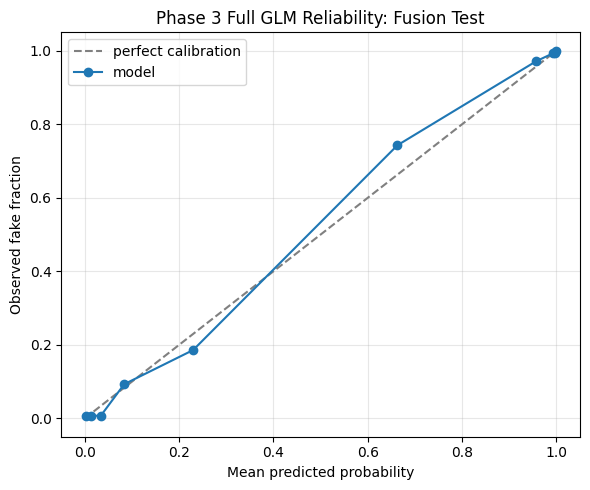

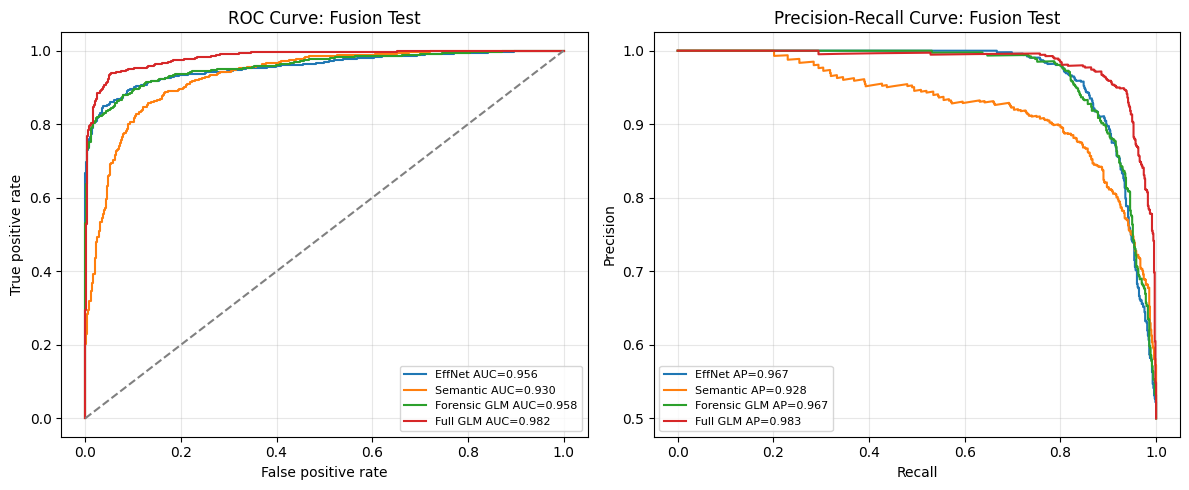

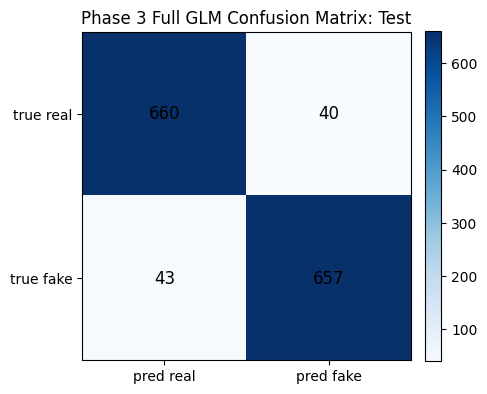

{
  "models": {
    "effnet_calibrated": {
      "validation": {
        "auc": 0.9532816326530612,
        "average_precision": 0.9642891923285402,
        "accuracy": 0.8992857142857142,
        "precision": 0.9267175572519084,
        "recall": 0.8671428571428571,
        "f1": 0.8959409594095941,
        "brier": 0.08281597381452865,
        "threshold": 0.56,
        "n": 1400,
        "tn": 652,
        "fp": 48,
        "fn": 93,
        "tp": 607
      },
      "test": {
        "auc": 0.9557857142857145,
        "average_precision": 0.966744418799238,
        "accuracy": 0.9028571428571428,
        "precision": 0.9392523364485982,
        "recall": 0.8614285714285714,
        "f1": 0.8986587183308494,
        "brier": 0.07793311227428751,
        "threshold": 0.56,
        "n": 1400,
        "tn": 661,
        "fp": 39,
        "fn": 97,
        "tp": 603
      },
      "test_at_0_5": {
        "auc": 0.9557857142857145,
        "average_precision": 0.966744418799238,
        

,model,feature,coefficient,abs_coefficient
11,full_forensic_semantic_glm,semantic_vit_logit,2.350880,2.350880
1,full_forensic_semantic_glm,effnet_prob,1.501513,1.501513
2,full_forensic_semantic_glm,effnet_calibrated_prob,1.154718,1.154718
12,full_forensic_semantic_glm,semantic_vit_prob,-0.528553,0.528553
4,full_forensic_semantic_glm,vae_recon_percentile,-0.522193,0.522193
0,full_forensic_semantic_glm,effnet_logit,0.435854,0.435854
14,full_forensic_semantic_glm,semantic_attention_focus,0.353799,0.353799
15,full_forensic_semantic_glm,semantic_self_attention_entropy,-0.228368,0.228368
3,full_forensic_semantic_glm,vae_recon_error,0.220682,0.220682
13,full_forensic_semantic_glm,semantic_attention_entropy,0.213870,0.213870


In [11]:
class Phase3FusionEvaluator:
    def __init__(self, config, paths):
        self.config = config
        self.paths = paths

    def collect_probs(self, val_df, test_df, forensic_glm, full_glm):
        val_probs = {
            "effnet_calibrated": val_df["effnet_calibrated_prob"].astype(float).values,
            "semantic_vit": val_df["semantic_vit_prob"].astype(float).values,
            "naive_effnet_semantic_average": (
                val_df["effnet_calibrated_prob"].astype(float).values
                + val_df["semantic_vit_prob"].astype(float).values
            ) / 2.0,
            "forensic_only_glm": forensic_glm.predict_proba(val_df),
            "full_forensic_semantic_glm": full_glm.predict_proba(val_df),
        }
        test_probs = {
            "effnet_calibrated": test_df["effnet_calibrated_prob"].astype(float).values,
            "semantic_vit": test_df["semantic_vit_prob"].astype(float).values,
            "naive_effnet_semantic_average": (
                test_df["effnet_calibrated_prob"].astype(float).values
                + test_df["semantic_vit_prob"].astype(float).values
            ) / 2.0,
            "forensic_only_glm": forensic_glm.predict_proba(test_df),
            "full_forensic_semantic_glm": full_glm.predict_proba(test_df),
        }
        return val_probs, test_probs

    def evaluate_all(self, val_df, test_df, forensic_glm, full_glm):
        if self.paths.metrics_json.exists() and not self.config.FORCE_REBUILD:
            print("Loading saved Phase 3 metrics:", self.paths.metrics_json)
            with open(self.paths.metrics_json, "r", encoding="utf-8") as f:
                metrics = json.load(f)
            print(json.dumps(metrics, indent=2))
            return metrics

        y_val = val_df["label"].astype(int).values
        y_test = test_df["label"].astype(int).values
        val_probs, test_probs = self.collect_probs(val_df, test_df, forensic_glm, full_glm)

        metrics = {"models": {}, "thresholds": {}, "subgroups": {}}
        threshold_rows = []
        for name in val_probs:
            best_threshold, sweep = choose_threshold_by_val_f1(
                y_val, val_probs[name], grid_size=self.config.threshold_grid_size
            )
            sweep["model"] = name
            threshold_rows.append(sweep)
            metrics["thresholds"][name] = best_threshold
            metrics["models"][name] = {
                "validation": classification_metrics(y_val, val_probs[name], threshold=best_threshold),
                "test": classification_metrics(y_test, test_probs[name], threshold=best_threshold),
                "test_at_0_5": classification_metrics(y_test, test_probs[name], threshold=0.5),
            }

        threshold_df = pd.concat(threshold_rows, axis=0, ignore_index=True)
        threshold_df.to_csv(self.paths.thresholds_csv, index=False)

        # Face/no-face subgroup check for the final model.
        final_probs = test_probs["full_forensic_semantic_glm"]
        final_threshold = metrics["thresholds"]["full_forensic_semantic_glm"]
        for face_value, group_df in test_df.groupby("face_present"):
            idx = group_df.index
            metrics["subgroups"][f"full_glm_face_present_{int(face_value)}"] = classification_metrics(
                group_df["label"].astype(int).values,
                final_probs[test_df.index.get_indexer(idx)],
                threshold=final_threshold,
            )

        coef_df = full_glm.coefficients()
        coef_df.to_csv(self.paths.coefficients_csv, index=False)
        save_json(metrics, self.paths.metrics_json)

        plot_reliability(
            y_test,
            test_probs["full_forensic_semantic_glm"],
            "Phase 3 Full GLM Reliability: Fusion Test",
            self.paths.plot_dir / "phase3_full_glm_reliability_test.png",
        )
        plot_roc_pr_curves(
            {
                "EffNet": test_probs["effnet_calibrated"],
                "Semantic": test_probs["semantic_vit"],
                "Forensic GLM": test_probs["forensic_only_glm"],
                "Full GLM": test_probs["full_forensic_semantic_glm"],
            },
            y_test,
            self.paths.plot_dir / "phase3_roc_pr_comparison_test.png",
        )
        plot_confusion_matrix_from_metrics(
            metrics["models"]["full_forensic_semantic_glm"]["test"],
            "Phase 3 Full GLM Confusion Matrix: Test",
            self.paths.plot_dir / "phase3_full_glm_confusion_matrix_test.png",
        )

        print(json.dumps(metrics, indent=2))
        display(coef_df)
        return metrics


phase3_evaluator = Phase3FusionEvaluator(CONFIG, PATHS)
phase3_metrics = phase3_evaluator.evaluate_all(val_df, test_df, forensic_glm, full_glm) if RUN_EVALUATION_STAGE else None

### What the Final Metrics and Plots Mean

This is the most important result in Phase 3. The full forensic + semantic GLM is the best model in the table.

On the held-out `fusion_test` split, the main numbers are:

```text
EfficientNet calibrated alone:
AUC = 0.9558, accuracy = 0.9029, F1 = 0.8987, Brier = 0.0779
FP = 39, FN = 97

Semantic ViT alone:
AUC = 0.9303, accuracy = 0.8593, F1 = 0.8631, Brier = 0.1134
FP = 118, FN = 79

Naive average:
AUC = 0.9763, accuracy = 0.9171, F1 = 0.9200, Brier = 0.0704
FP = 83, FN = 33

Forensic-only GLM:
AUC = 0.9578, accuracy = 0.8971, F1 = 0.8944, Brier = 0.0747
FP = 54, FN = 90

Full forensic + semantic GLM:
AUC = 0.9819, accuracy = 0.9407, F1 = 0.9406, Brier = 0.0493
FP = 40, FN = 43
```

The key comparison is the full GLM against the forensic-only GLM. The full GLM is better on every important test metric:

```text
AUC:      0.9578 -> 0.9819
accuracy: 0.8971 -> 0.9407
F1:       0.8944 -> 0.9406
Brier:    0.0747 -> 0.0493
```

That is the main evidence that Phase 2 helped. The semantic attention branch is not just decoration. It adds information that the forensic-only branch did not fully capture.

The comparison against EfficientNet alone is also important. EfficientNet was already strong, but the full GLM catches many more fake images without creating many more false alarms:

```text
EfficientNet calibrated: FP = 39, FN = 97
Full GLM:                FP = 40, FN = 43
```

So the final model catches **54 more fake images** than EfficientNet calibrated alone, while adding only **one extra false positive** on this test split. That is probably the clearest practical result in the notebook.

The naive average is useful as a sanity check. It does well because EfficientNet and semantic ViT really are complementary. But it creates many more false positives:

```text
Naive average: FP = 83, FN = 33
Full GLM:      FP = 40, FN = 43
```

The average catches 10 more fakes, but it wrongly accuses 43 more real images. The GLM gives a better balance: it keeps recall high while cutting the false positives almost in half. This is why I do not use naive averaging as the final method.

The threshold also tells a story. The full GLM chooses `0.42` on validation, not `0.50`. That means the best F1 tradeoff came from being slightly more willing to call an image fake. At threshold `0.50`, the full GLM has fewer false positives but misses more fakes. At threshold `0.42`, it improves recall and F1, which fits the detector goal.

The reliability plot is good overall. The blue curve stays close to the diagonal, especially in the high-probability region where the model is most confident. That means the GLM probability is not just a ranking score; it is fairly usable as a probability estimate. It is not perfect in the middle bins, but the Brier score of `0.0493` is much better than the single-branch models.

The ROC/PR plot shows the same result visually. The red full-GLM curve sits above the other curves. In ROC space it has the best AUC (`0.982`). In precision-recall space it has the best average precision (`0.983`). This means the fusion model gives the best ranking and the best high-precision/high-recall tradeoff.

The confusion matrix makes the result concrete:

```text
660 real images correctly called real
40 real images wrongly called fake
43 fake images wrongly called real
657 fake images correctly called fake
```

So out of 1,400 test images, the full GLM gets 1,317 right. More importantly, the mistakes are balanced: it is not only protecting precision by missing many fakes, and it is not only increasing recall by flagging too many real images.

The face subgroup results are also useful:

```text
No-face images:
AUC = 0.9805, accuracy = 0.9375, F1 = 0.9381

Face-present images:
AUC = 0.9913, accuracy = 0.9643, F1 = 0.9610
```

This supports the face-gated design. The model is especially strong when a valid face is present, but it is still very strong when no face is present. That means the final detector is not depending only on OpenForensics. The broad forensic and semantic branches still carry the no-face cases.


<a id="phase3-coefficients"></a><a name="phase3-coefficients"></a>

## 12. Plot GLM Coefficients

The coefficients are one reason I like the GLM. They let me explain which evidence sources the final model trusted.

Because the model uses `StandardScaler`, the coefficients are standardized. A larger absolute value means a larger effect for a one-standard-deviation change in that feature.


,model,feature,coefficient,abs_coefficient
0,full_forensic_semantic_glm,semantic_vit_logit,2.350880,2.350880
1,full_forensic_semantic_glm,effnet_prob,1.501513,1.501513
2,full_forensic_semantic_glm,effnet_calibrated_prob,1.154718,1.154718
3,full_forensic_semantic_glm,semantic_vit_prob,-0.528553,0.528553
4,full_forensic_semantic_glm,vae_recon_percentile,-0.522193,0.522193
5,full_forensic_semantic_glm,effnet_logit,0.435854,0.435854
6,full_forensic_semantic_glm,semantic_attention_focus,0.353799,0.353799
7,full_forensic_semantic_glm,semantic_self_attention_entropy,-0.228368,0.228368
8,full_forensic_semantic_glm,vae_recon_error,0.220682,0.220682
9,full_forensic_semantic_glm,semantic_attention_entropy,0.213870,0.213870


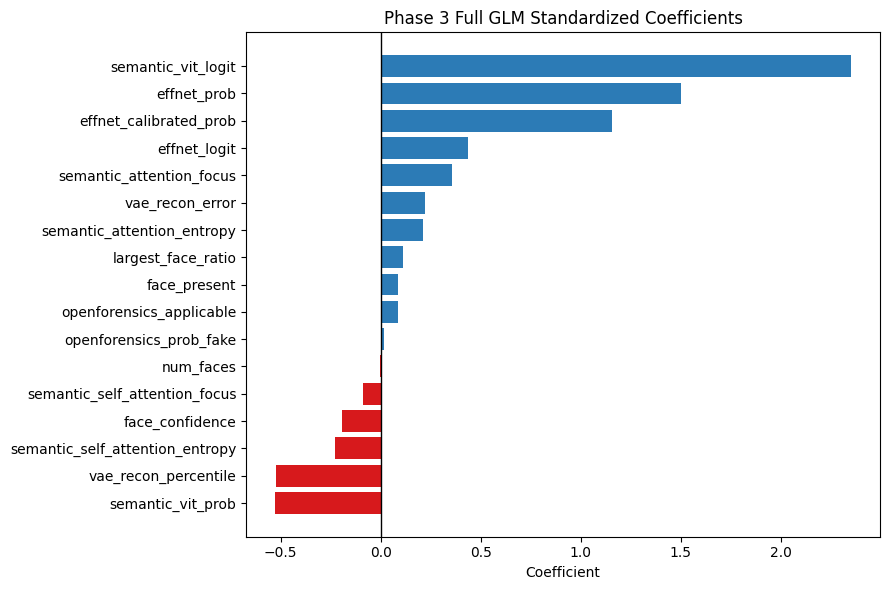

In [12]:
def plot_coefficients(coef_df, output_path, top_n=17):
    plot_df = coef_df.sort_values("coefficient").tail(top_n)
    plt.figure(figsize=(9, 6))
    colors = ["#2C7BB6" if v >= 0 else "#D7191C" for v in plot_df["coefficient"]]
    plt.barh(plot_df["feature"], plot_df["coefficient"], color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Phase 3 Full GLM Standardized Coefficients")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=160)
    plt.show()


if PATHS.coefficients_csv.exists():
    coef_df = pd.read_csv(PATHS.coefficients_csv)
else:
    coef_df = full_glm.coefficients()
    coef_df.to_csv(PATHS.coefficients_csv, index=False)

display(coef_df.sort_values("abs_coefficient", ascending=False))
plot_coefficients(coef_df, PATHS.plot_dir / "phase3_full_glm_coefficients.png")

### What the Coefficients Mean

The coefficient plot explains what the GLM trusted.

The biggest positive coefficient is:

```text
semantic_vit_logit = +2.3509
```

This is a very important result. It means the semantic branch became the strongest feature in the final meta-layer. So Phase 2 did not just add a small side signal. The learned fusion model strongly used the semantic ViT logit when deciding fake vs real.

The next strongest features are EfficientNet features:

```text
effnet_prob = +1.5015
effnet_calibrated_prob = +1.1547
effnet_logit = +0.4359
```

This confirms that Phase 1 is still central. The final model did not abandon the forensic detector. It combined the semantic branch with the strongest low-level forensic signal.

One thing that looks strange at first is:

```text
semantic_vit_logit = positive
semantic_vit_prob  = negative
```

I would not read this as "semantic probability means real." These two columns are highly related versions of the same semantic score. Logistic regression can split weight between correlated features in unintuitive ways, especially after scaling. The safer interpretation is that the semantic branch matters strongly overall, and the raw logit is the version the GLM trusted most.

The attention feature result is also useful:

```text
semantic_attention_focus = +0.3538
```

This means that, after the semantic transformer processed the image patches, more concentrated attention pooling pushed the final prediction toward fake. That fits the idea that suspicious semantic evidence may live in a few important regions rather than being evenly spread across the whole image.

The VAE features are smaller and mixed:

```text
vae_recon_error = +0.2207
vae_recon_percentile = -0.5222
```

This supports the earlier Phase 1 conclusion. The VAE branch has some signal, but it is not the main detector. It is useful as one feature inside the GLM, not as the final decision rule.

The face/OpenForensics features are small:

```text
openforensics_prob_fake = +0.0169
face_present = +0.0880
openforensics_applicable = +0.0880
```

This does not mean the face branch was pointless. It means that on the full Tiny-GenImage fusion split, only a subset of images have valid faces, so the broad EfficientNet and semantic ViT signals dominate the global coefficient table. The subgroup result still shows the final model performs especially well on face-present images.

Overall, the coefficient plot supports the main story:

```text
Phase 2 semantic logit is the strongest new signal.
Phase 1 EfficientNet remains very important.
VAE and OpenForensics act as smaller supporting evidence.
The learned GLM is better than manual averaging because it learns these weights from data.
```


<a id="phase3-summary"></a><a name="phase3-summary"></a>

## 13. Final Executive Summary

This notebook is the final Phase 3 fusion layer. The expensive image models were already trained in Phase 1 and Phase 2. Here I use their saved outputs as evidence features and train one interpretable GLM on top.

The final pipeline is:

```text
Phase 1 forensic branch
EfficientNet + VAE + FaceGate/OpenForensics

Phase 2 semantic branch
ViT patch tokens + custom multi-head attention head

Phase 3 fusion branch
forensic features + semantic features -> GLM -> final fake probability
```

The data alignment worked correctly. Phase 1 had 7,000 forensic rows, Phase 2 had the matching 7,000 semantic rows, and the merged fusion table kept all 7,000 aligned images. I then split them into 4,200 fusion-train images, 1,400 fusion-validation images, and 1,400 fusion-test images, with perfectly balanced real/fake labels in each split.

The final test result is strong:

```text
Full forensic + semantic GLM
AUC = 0.9819
accuracy = 0.9407
precision = 0.9426
recall = 0.9386
F1 = 0.9406
Brier = 0.0493
```

The most important comparison is against EfficientNet calibrated alone:

```text
EfficientNet calibrated: FP = 39, FN = 97
Full GLM:                FP = 40, FN = 43
```

So the full system catches 54 more fake images while adding only one extra false positive. That is the cleanest evidence that the semantic layer helped.

The full GLM also beats the forensic-only GLM:

```text
forensic-only GLM F1 = 0.8944
full forensic + semantic GLM F1 = 0.9406
```

This means the semantic attention branch added real complementary signal beyond the forensic features. The coefficient plot supports the same conclusion: `semantic_vit_logit` has the largest standardized coefficient, while EfficientNet features remain the next strongest signals.

The final takeaway is that the layered design worked. Phase 1 captures low-level forensic evidence. Phase 2 captures semantic patch-relationship evidence. Phase 3 learns how much to trust each signal instead of averaging them by hand. This gives me a final detector that is stronger, more calibrated, and easier to explain than any single branch alone.


<a id="phase3-references"></a><a name="phase3-references"></a>

## 14. References

- McCullagh and Nelder. *Generalized Linear Models.*
- scikit-learn documentation: `LogisticRegression`, `Pipeline`, `StandardScaler`.
- Phase 1 AI Shield notebook: forensic EfficientNet, VAE, OpenForensics, and branch-output cache.
- Phase 2 AI Shield notebook: ViT semantic transformer attention branch and semantic branch-output cache.
- Vaswani et al. "Attention Is All You Need." 2017.
- Dosovitskiy et al. "An Image is Worth 16x16 Words." 2020.
